# Chromatin Loops Connection with Age

This notebook examines the relationship between chromatin loops intensity and age in SZ and Healthy samples.

In [ ]:
import pandas as pdimport numpy as npfrom itertools import chainfrom tqdm import tqdmimport osfrom os import listdirimport globimport jsonimport seaborn as snsimport coolerimport bioframeimport cooltoolsfrom matplotlib_venn import venn2from cooltools.lib.numutils import fill_diagfrom statsmodels.stats.multitest import multipletestsfrom os.path import isfile, joinimport warningsimport loggingimport mathimport matplotlib.pyplot as pltimport scipyimport bioframe as bfimport scipy.stats as statsfrom statannot import add_stat_annotationfrom scipy.stats import ttest_indfrom scipy.stats import mannwhitneyuimport pyranges as prfrom pybedtools import BedTool as pbtimport upsetplotimport gseapy as gpfrom gseapy import barplot, dotplotimport rpy2from statsmodels.stats.multitest import fdrcorrectionfrom collections import defaultdictimport concurrent.futuresfrom scipy.stats import fisher_exactfrom matplotlib.colors import PowerNormfrom dotenv import load_dotenvassert os.environ['CONDA_DEFAULT_ENV'] == "hic"

# Chromatin Loops Connection with Age

This notebook examines the relationship between chromatin loops intensity and age in SZ and Healthy samples.

In [4]:
save_name = "loops_SZ_vs_Healthy"path_to_loops_clusters_data = "./loops_cooltools_data_noSexChromosomes/loops_clusters_data_15kb"name_appender="_reducedFiltering"merged_all_clusters =pd.read_pickle(f"{path_to_loops_clusters_data}/{save_name}_calculated_clusters_all{name_appender}.pickle")merged_all_clusters['num'] = [i for i in range(merged_all_clusters.shape[0])]merged_all_clusters['group'] = merged_all_clusters.source.apply(lambda x: "SZ" if "SZ" in x else "Healthy")

In [6]:
samples_with_age = {'HC-2Mplus': 62,'HC-3Mplus': 36,'HC-91plus': 59,'HC24plus': 54,'HC-318plus': 58,'HCM12plus': 35,'SZ-01plus': 36,'SZ-03plus': 57,'SZ08plus': 56,'SZ10plus': 50,'SZ20plus': 37,'SZ6plus': 62}age_group = {}for label, age in samples_with_age.items():    if age <= 40:        age_group[label] = "Young"    elif 40 < age <= 57:        age_group[label] = "Adult"    else:        age_group[label] = "Adult"merged_all_clusters['sample_name'] = merged_all_clusters.source.apply(lambda x: x.split("_")[0])merged_all_clusters['age_group'] = merged_all_clusters['sample_name'].map(age_group)df = merged_all_clusters[[ 'num','cluster', 'intensity_mean', 'intensity_median', 'group', 'age_group']]

In [21]:
sizes = merged_all_clusters[['chrom1', 'start1', 'start2', 'cluster']].groupby('cluster').mean().reset_index().round(0)sizes = sizes.merge(merged_all_clusters[['cluster', 'chrom1']].drop_duplicates().reset_index(drop=True), on ='cluster', how='left')sizes = sizes[['chrom1','start1', 'start2', 'cluster']].reset_index(drop=True)sizes = sizes.sort_values(['chrom1', 'start2']).reset_index(drop=True)sizes_loops =sizes.copy()sizes_loops['size'] = sizes_loops['start2'] - sizes_loops['start1']quantiles = np.quantile(sizes_loops['size'], [0, 0.33, 0.67, 1.0])print(quantiles)

[ 127500.  302500.  528750. 3721250.]


In [24]:
quantiles = np.quantile(sizes_loops['size'], [0, 0.33, 0.67, 1.0])print(quantiles) size_labels = ['small', 'medium', 'large']sizes_loops['size_group'] = pd.cut(    sizes_loops['size'],    bins=quantiles,    labels=size_labels,    include_lowest=True,    duplicates='drop'  )

[ 127500.  302500.  528750. 3721250.]


In [54]:
sizes_loops.groupby('size_group').mean()

,start1,start2,size
size_group,,,
small,8.007096e+07,8.029672e+07,225760.261194
medium,8.219544e+07,8.259428e+07,398846.153846
large,8.068365e+07,8.161013e+07,926473.240046


In [51]:
def get_cluster_group_stats(df, group_col, stat_col, group1, group2):    out = (        df[df[group_col].isin([group1, group2])]        .groupby(['cluster', group_col])[stat_col]        .median()        .unstack()        .rename(columns={group1: f"{group_col}_{group1}", group2: f"{group_col}_{group2}"})    )    return outdef loops_size_group_analysis(    df,     sizes_tads,    border_size_group_value,     N_QUANTILES=10,     group_col='group',    stat_col='intensity_median',    cluster_col='cluster',    border_group_col='size_group',    age_group_col='age_group',    plot_prefix='./figures_loops_analysis_extended/loops',    apply_filter=True):    sel_cl = sizes_tads[sizes_tads[border_group_col] == border_size_group_value].cluster.tolist()    if apply_filter:            sub_df = df[df["cluster"].isin(sel_cl)]    else:        sub_df= df.copy()    sz_hc = get_cluster_group_stats(sub_df, group_col, stat_col, 'SZ', 'Healthy')    sz_hc['sz_hc_log2fc'] = np.log2(sz_hc['group_SZ'] / sz_hc['group_Healthy'])    healthy = sub_df[sub_df[group_col] == 'Healthy']    hc_age = (        healthy.groupby([cluster_col, age_group_col])[stat_col]        .median()        .unstack()        .rename(columns={'Young':'HC_Young', 'Adult':'HC_Adult'})    )    hc_age['hc_old_young_log2fc'] = np.log2(hc_age['HC_Adult'] / hc_age['HC_Young'])    merged = pd.merge(sz_hc, hc_age, left_index=True, right_index=True, how='inner').dropna(        subset=['sz_hc_log2fc','hc_old_young_log2fc'])    merged['sz_hc_quantile'] = pd.qcut(        merged['sz_hc_log2fc'], N_QUANTILES, labels=False, duplicates='drop')    merged['hc_old_young_quantile'] = pd.qcut(        merged['hc_old_young_log2fc'], N_QUANTILES, labels=False, duplicates='drop')    top_sz_hc = merged[merged['sz_hc_quantile'] == merged['sz_hc_quantile'].max()].index    top_hc_age = merged[merged['hc_old_young_quantile'] == merged['hc_old_young_quantile'].max()].index    overlap_clusters = set(top_sz_hc) & set(top_hc_age)    print(f'[border_size_group={border_size_group_value}] Number of top_sz_hc: {len(top_sz_hc)}')    print(f'[border_size_group={border_size_group_value}] Number of top_hc_age: {len(top_hc_age)}')    print(f'[border_size_group={border_size_group_value}] Number of overlapping clusters in top quantile: {len(overlap_clusters)}')    # --- Fisher's exact test for enrichment ---    # | in_top_SZ_and_top_HC | in_top_SZ_not_in_top_HC |    # |----------------------|------------------------ |    # | in_top_HC_not_top_SZ | in_neither             |    table = [        [len(set(top_sz_hc) & set(top_hc_age)), len(set(top_sz_hc) - set(top_hc_age))],        [len(set(top_hc_age) - set(top_sz_hc)), len(merged) - len(set(top_sz_hc) | set(top_hc_age))]    ]    oddsratio, pval = fisher_exact(table, alternative='greater')    print(f"[border_size_group={border_size_group_value}] Fisher's exact test p-value for enrichment: {pval:.3g}, odds ratio: {oddsratio:.3g}")    # --- Quantile intersection matrices ---    TOTAL_NUM = len(merged.index)    similarity_matrix = np.zeros((N_QUANTILES, N_QUANTILES))    intersection_percentage_matrix = np.zeros((N_QUANTILES, N_QUANTILES))    for i in range(N_QUANTILES):        sz_clusters = set(merged[merged['sz_hc_quantile'] == i].index)        sz_size = len(sz_clusters)        for j in range(N_QUANTILES):            hc_clusters = set(merged[merged['hc_old_young_quantile'] == j].index)            intersection = len(sz_clusters & hc_clusters)            union = len(sz_clusters | hc_clusters)            similarity = (intersection / union) if union > 0 else 0            similarity_matrix[i, j] = similarity            if sz_size > 0:                intersection_percentage_matrix[i, j] = intersection / TOTAL_NUM            else:                intersection_percentage_matrix[i, j] = 0    plt.rcParams["svg.fonttype"] = "none"    plt.figure(figsize=(8,7))    ax = sns.heatmap(        similarity_matrix,        annot=True,        fmt=".2f",        cmap='Blues',        norm=PowerNorm(gamma=0.5),        xticklabels=[f'Q{i+1}' for i in range(N_QUANTILES)],        yticklabels=[f'Q{i+1}' for i in range(N_QUANTILES)]    )    ax.xaxis.tick_top()    ax.xaxis.set_label_position('top')    plt.xticks(rotation=45, ha='left')    plt.title(f'Jaccard similarity (cluster={border_size_group_value})', pad=20)    plt.xlabel('HC Adult/Young quantiles')    plt.ylabel('SZ/HC quantiles')    plt.tight_layout()    plt.savefig(f'{plot_prefix}_q{N_QUANTILES}_jaccard_cluster_{border_size_group_value}.pdf', bbox_inches='tight')    plt.savefig(f'{plot_prefix}_q{N_QUANTILES}_jaccard_cluster_{border_size_group_value}.svg', bbox_inches='tight')    plt.show()    plt.figure(figsize=(8,7))    ax = sns.heatmap(        intersection_percentage_matrix,        annot=True,        fmt=".1%",        cmap='Blues',        xticklabels=[f'HCa/HCy Q{i+1}' for i in range(N_QUANTILES)],        yticklabels=[f'SZ/HC Q{i+1}' for i in range(N_QUANTILES)]    )    ax.xaxis.tick_top()    ax.xaxis.set_label_position('top')    plt.xticks(rotation=45, ha='left')    plt.title(f'Intersection Percentage vs SZ/HC size (cluster={border_size_group_value})', pad=20)    plt.xlabel('HC Adult/Young quantiles')    plt.ylabel('SZ/HC quantiles')    plt.tight_layout()    plt.savefig(f'{plot_prefix}_q{N_QUANTILES}_intersection_cluster_{border_size_group_value}.pdf', bbox_inches='tight')    plt.savefig(f'{plot_prefix}_q{N_QUANTILES}_intersection_cluster_{border_size_group_value}.svg', bbox_inches='tight')    plt.show()    return merged, similarity_matrix, intersection_percentage_matrix

[border_size_group=large] Number of top_sz_hc: 347
[border_size_group=large] Number of top_hc_age: 347
[border_size_group=large] Number of overlapping clusters in top quantile: 53
[border_size_group=large] Fisher's exact test p-value for enrichment: 0.000732, odds ratio: 1.73


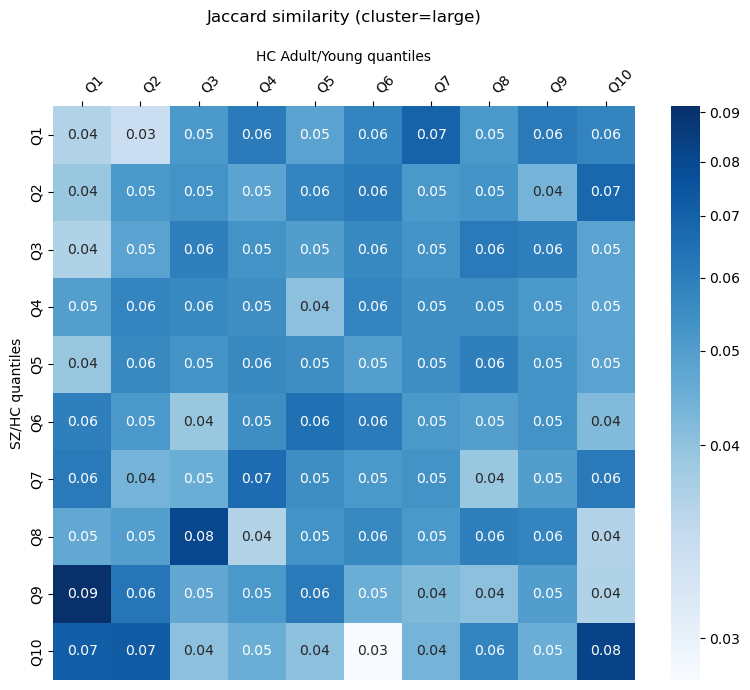

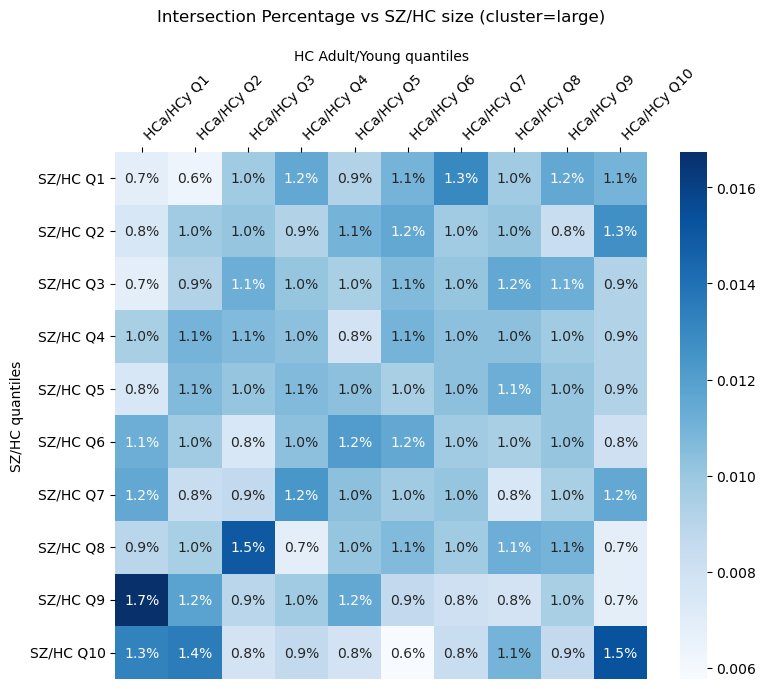

In [47]:
merged, similarity_matrix, intersection_percentage_matrix = loops_size_group_analysis(df,sizes_loops,  border_size_group_value='large')

[border_size_group=medium] Number of top_sz_hc: 358
[border_size_group=medium] Number of top_hc_age: 358
[border_size_group=medium] Number of overlapping clusters in top quantile: 43
[border_size_group=medium] Fisher's exact test p-value for enrichment: 0.111, odds ratio: 1.26


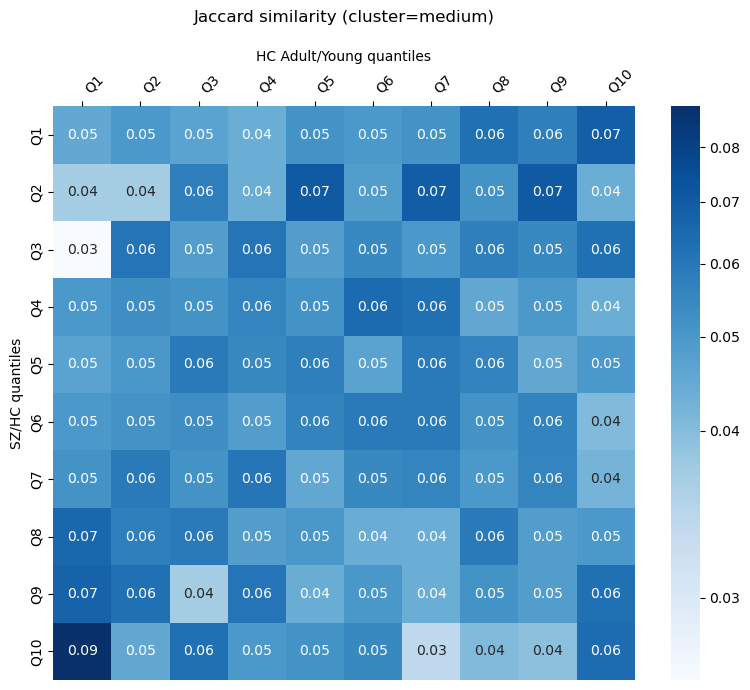

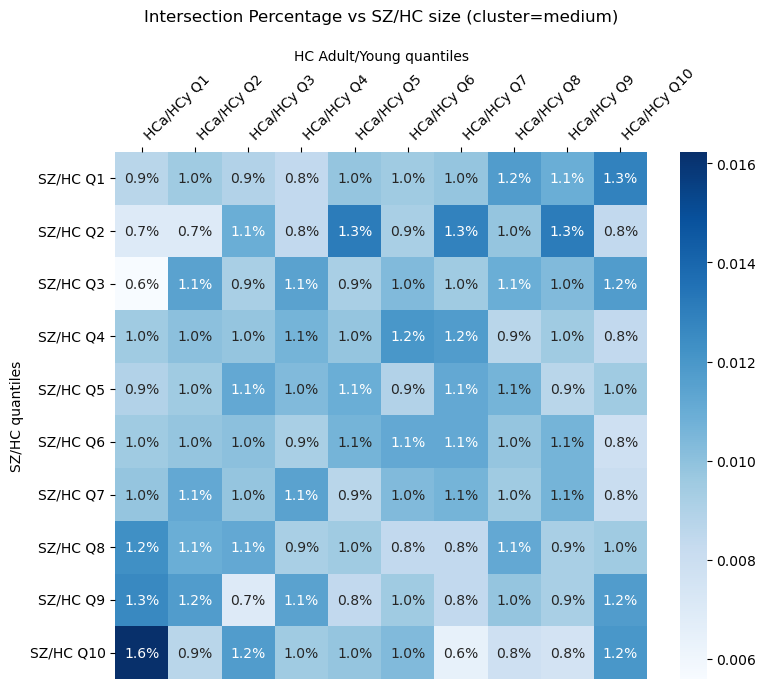

In [48]:
merged, similarity_matrix, intersection_percentage_matrix = loops_size_group_analysis(df,sizes_loops,  border_size_group_value='medium')

[border_size_group=small] Number of top_sz_hc: 349
[border_size_group=small] Number of top_hc_age: 349
[border_size_group=small] Number of overlapping clusters in top quantile: 28
[border_size_group=small] Fisher's exact test p-value for enrichment: 0.923, odds ratio: 0.764


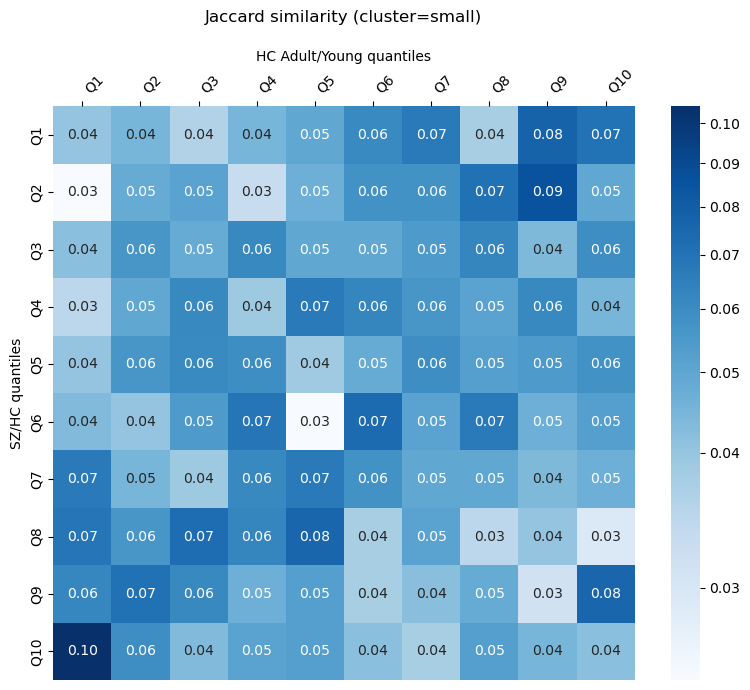

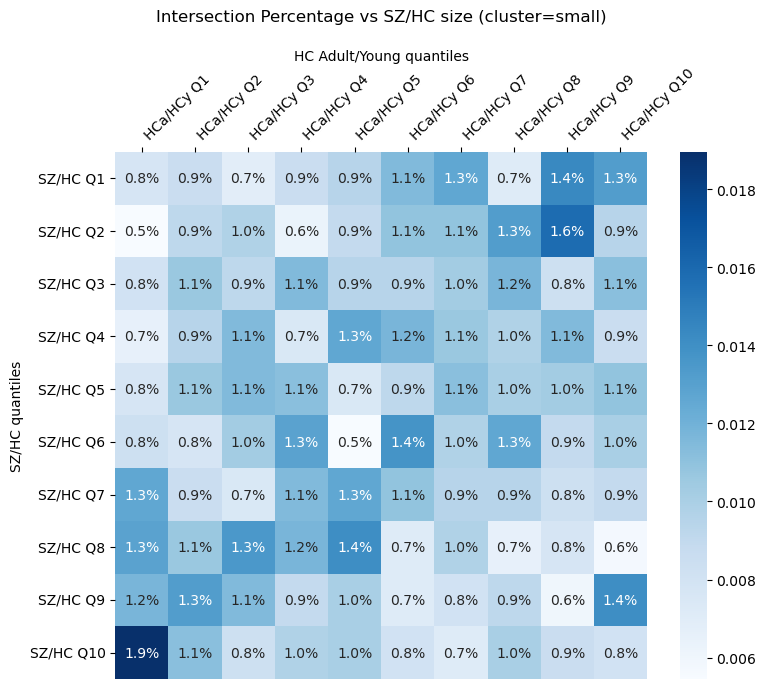

In [49]:
merged, similarity_matrix, intersection_percentage_matrix = loops_size_group_analysis(df,sizes_loops,  border_size_group_value='small')

[border_size_group=ALL] Number of top_sz_hc: 1053
[border_size_group=ALL] Number of top_hc_age: 1053
[border_size_group=ALL] Number of overlapping clusters in top quantile: 133
[border_size_group=ALL] Fisher's exact test p-value for enrichment: 0.00213, odds ratio: 1.34


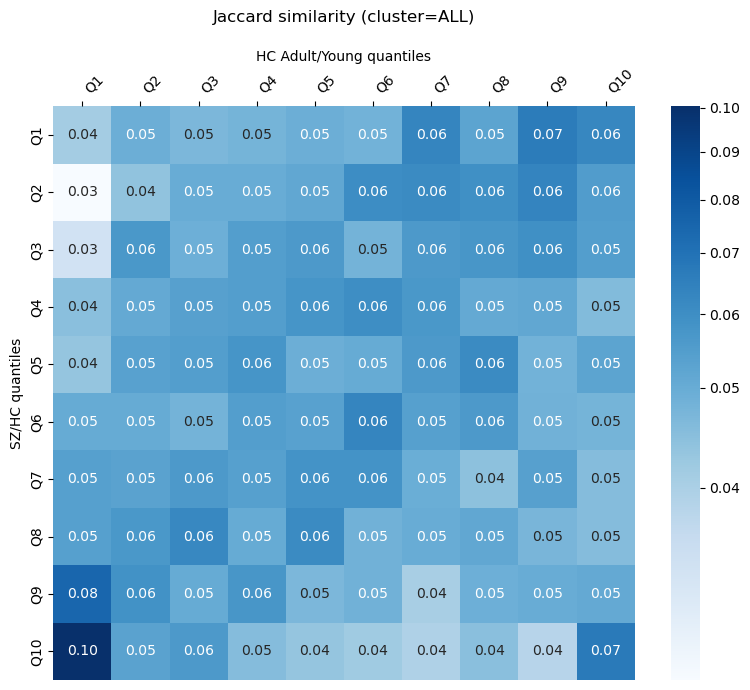

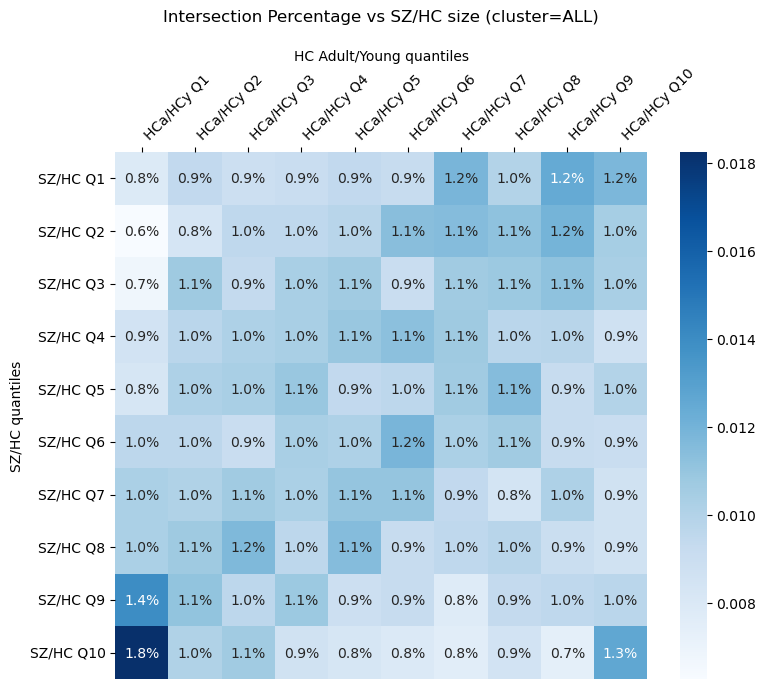

In [52]:
merged, similarity_matrix, intersection_percentage_matrix = loops_size_group_analysis(df,sizes_loops,  border_size_group_value='ALL', apply_filter=False)